[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/15_matplotlib_graphiques.ipynb)

# Matplotlib : les graphiques du machine learning

Le premier notebook couvrait la mécanique de Matplotlib : créer une figure,
l'habiller, l'enregistrer. Celui-ci part dans l'autre sens. On prend un vrai jeu
de données et on cherche à en tirer quelque chose.

La question n'est plus "comment tracer une courbe", mais "quel graphique répond
à ma question".

## Le jeu de données

Iris est le jeu de données le plus utilisé pour apprendre. Il rassemble 150
fleurs de trois espèces différentes, mesurées chacune sur quatre variables : la
longueur et la largeur du sépale, la longueur et la largeur du pétale.

Il est petit, propre, et surtout il a une structure visible : deux des trois
espèces se séparent nettement sur certaines variables. C'est ce qui en fait un
bon terrain pour comprendre à quoi sert un graphique en machine learning.

## Les six graphiques du notebook

| Graphique | Ce qu'il montre | La question à laquelle il répond |
|---|---|---|
| `scatter` | deux variables, un point par individu | mes classes sont-elles séparables ? |
| `scatter` 3D et `plot_surface` | trois dimensions | la troisième variable apporte-t-elle quelque chose ? |
| `hist` | la distribution d'une variable | quelle échelle, quelle forme, quelles valeurs aberrantes ? |
| `hist2d` | la densité de deux variables | où mes observations se concentrent-elles ? |
| `contour` | une fonction de deux variables | où sont les minima et les maxima ? |
| `imshow` | une matrice | quelles variables sont redondantes ? |

## La démarche

Chaque section suit le même mouvement : on trace la version naïve, on regarde ce
qui cloche, on corrige. Les erreurs sont volontairement conservées, parce que
c'est en voyant un graphique raté qu'on comprend ce que fait chaque paramètre.

Prérequis : le notebook précédent sur les bases de Matplotlib, et savoir
manipuler un tableau NumPy à deux dimensions.

## 1. Charger et inspecter les données

Avant tout graphique, il faut savoir ce qu'on manipule. Trois informations
suffisent : la forme du tableau, le nom des variables, le nom des classes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
x = iris.data # (150, 4) : 150 fleurs, 4 mesures
y = iris.target # (150,) : l'espèce de chaque fleur, codée 0, 1 ou 2

print(f'x contient {x.shape[0]} exemples et {x.shape[1]} variables')
print(f'Il y a {np.unique(y).size} classes')
print('Variables :', iris.feature_names)
print('Classes :', list(iris.target_names))

x contient 150 exemples et 4 variables
Il y a 3 classes
Variables : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


La convention est toujours la même : une ligne est un individu, une colonne est
une variable. `x[:, 0]` se lit donc "toutes les lignes, colonne 0", c'est-à-dire
la première mesure de toutes les fleurs.

Le tableau `y` contient une valeur par fleur, dans le même ordre. La fleur
`x[0]` a pour espèce `y[0]`. Cette correspondance ligne à ligne est ce qui
permettra de colorer les points par classe.

In [ ]:
print('Les 3 premières fleurs :')
print(x[:3])
print('Leurs espèces :', y[:3])
print('La colonne 0 seule :', x[:, 0][:5])
print('Sa longueur :', len(x[:, 0]))

Les 3 premières fleurs :
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
Leurs espèces : [0 0 0]
La colonne 0 seule : [5.1 4.9 4.7 4.6 5. ]
Sa longueur : 150


## 2. Le nuage de points

`scatter` prend deux vecteurs de même longueur et place un point par paire. Ici,
un point par fleur.

Commençons par la version la plus simple : la longueur du sépale en abscisse, sa
largeur en ordonnée.

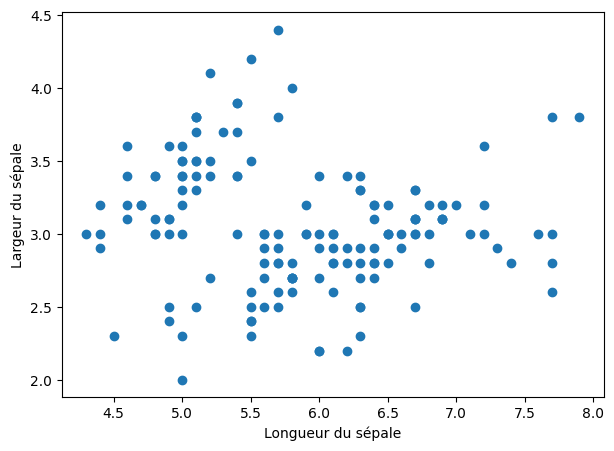

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(x[:, 0], x[:, 1])
plt.xlabel('Longueur du sépale')
plt.ylabel('Largeur du sépale')
plt.show()

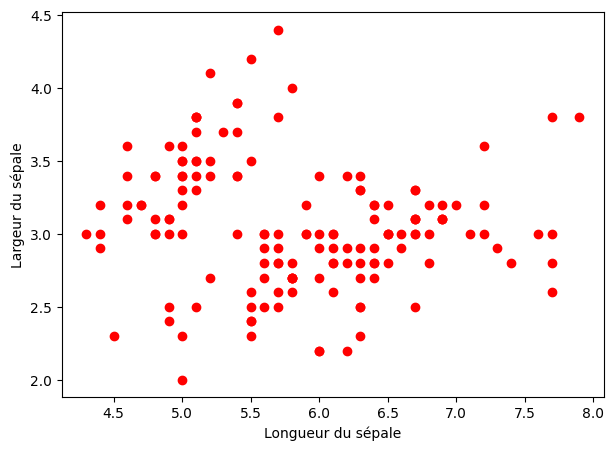

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(x[:, 0], x[:, 1], c='red')
plt.xlabel('Longueur du sépale')
plt.ylabel('Largeur du sépale')
plt.show()

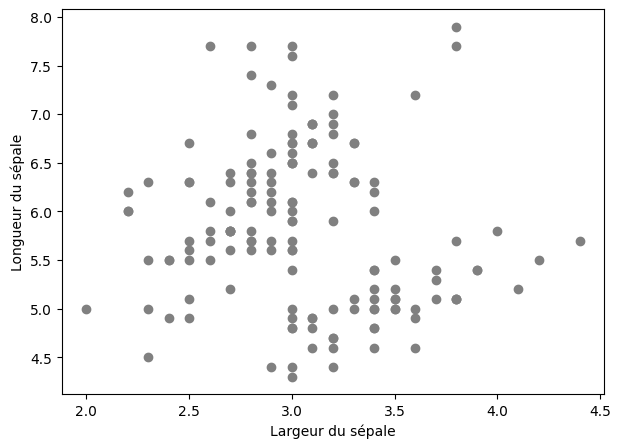

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(x[:, 1], x[:, 0], c='gray')
plt.xlabel('Largeur du sépale')
plt.ylabel('Longueur du sépale')
plt.show()

Un nuage informe. On voit qu'il y a des fleurs, on ne voit rien d'autre. C'est
normal : le graphique ignore complètement l'information la plus intéressante,
l'espèce de chaque fleur.

### Ajouter la classe avec l'argument c

En passant le tableau `y` à l'argument `c`, Matplotlib attribue une couleur
différente à chaque valeur. Le graphique change de nature.

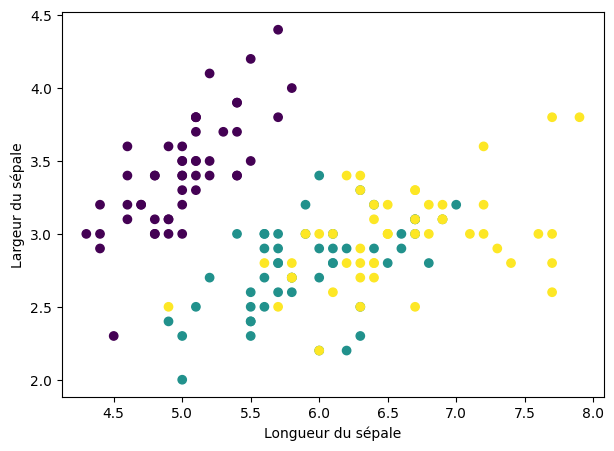

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(x[:, 0], x[:, 1], c=y)
plt.xlabel('Longueur du sépale')
plt.ylabel('Largeur du sépale')
plt.show()

Cette fois, une information apparaît : une des trois espèces se détache
nettement en bas à gauche, les deux autres restent mélangées. C'est exactement
le genre de constat qu'on cherche avant d'entraîner un modèle.

### Le rôle de alpha

Sur un nuage dense, des points se superposent sans qu'on le voie. La
transparence révèle ces zones : plus la couleur est soutenue, plus il y a de
points au même endroit.

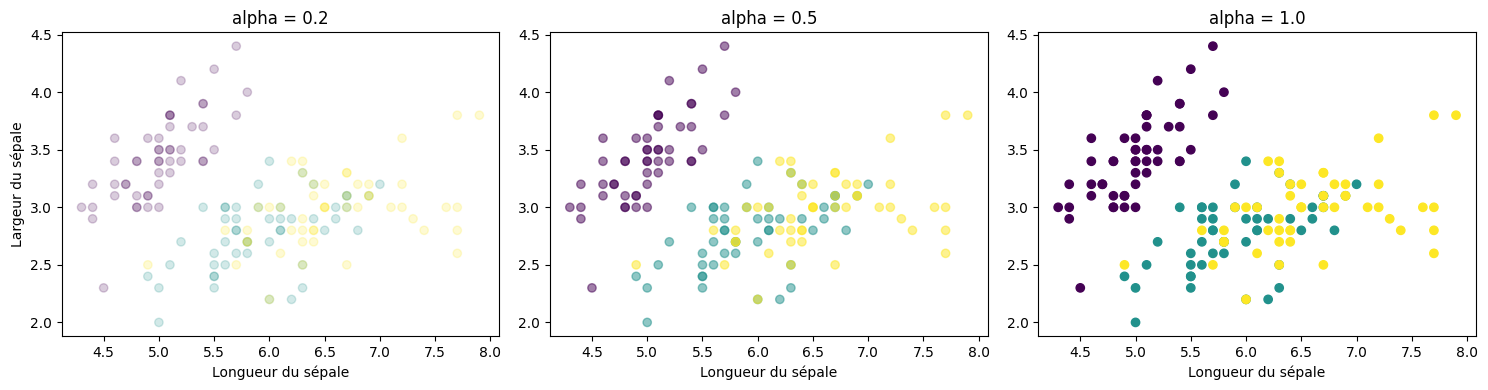

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for i, a in enumerate([0.2, 0.5, 1.0]):
    ax[i].scatter(x[:, 0], x[:, 1], c=y, alpha=a)
    ax[i].set_title(f'alpha = {a}')
    ax[i].set_xlabel('Longueur du sépale')

ax[0].set_ylabel('Largeur du sépale')
plt.tight_layout()
plt.show()

À `alpha=0.2` le nuage est presque effacé, à `alpha=1` on perd les
superpositions. Entre 0,5 et 0,7 est en général un bon compromis.

### Encoder une troisième variable avec la taille

L'argument `s` accepte lui aussi un tableau. On peut donc faire porter la taille
des points par une variable supplémentaire, ce qui permet d'en afficher trois
sur un graphique en deux dimensions.

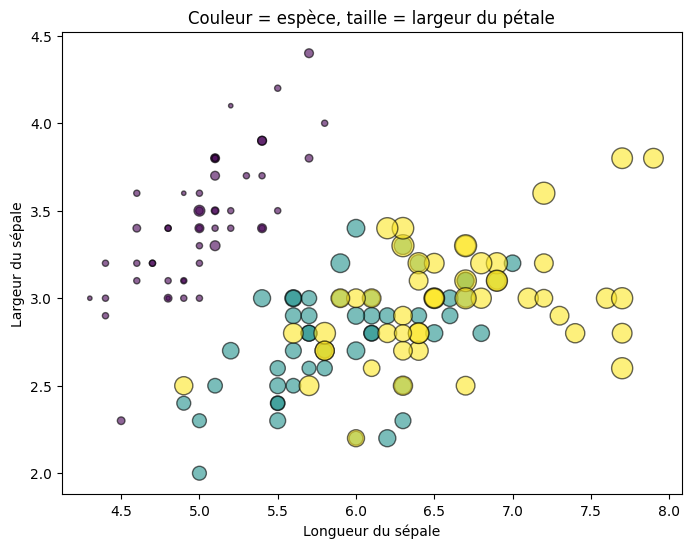

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1], c=y, s=x[:, 3] * 100, alpha=0.6, edgecolors='black')
# la taille dépend de la largeur du pétale
plt.xlabel('Longueur du sépale')
plt.ylabel('Largeur du sépale')
plt.title('Couleur = espèce, taille = largeur du pétale')
plt.show()

Le facteur 100 n'a rien de scientifique. L'argument `s` s'exprime en points au
carré, et les largeurs de pétale valent entre 0,1 et 2,5 : sans multiplication,
les points seraient invisibles. Ce genre d'ajustement empirique est courant, et
c'est une raison de plus d'indiquer dans le titre ce que la taille représente.

Ce graphique dit quelque chose d'intéressant : les gros points sont tous d'une
même couleur. La largeur du pétale est donc liée à l'espèce, alors que les
mesures du sépale seules ne suffisaient pas à séparer les classes. C'est une
piste que la section suivante va confirmer.

## 3. Comparer toutes les variables : la grille

Avec quatre variables, il existe seize combinaisons possibles. Les tracer une
par une serait fastidieux, et surtout on ne pourrait pas les comparer d'un coup
d'oeil.

La tentation naturelle est d'écrire une double boucle :

```python
for i in range(4):
    for j in range(4):
        plt.scatter(x[:, i], x[:, j])
```

Le résultat est illisible. Rien dans cette boucle ne crée de nouvelle figure :
les seize nuages se superposent tous au même endroit. Essayons pour voir.

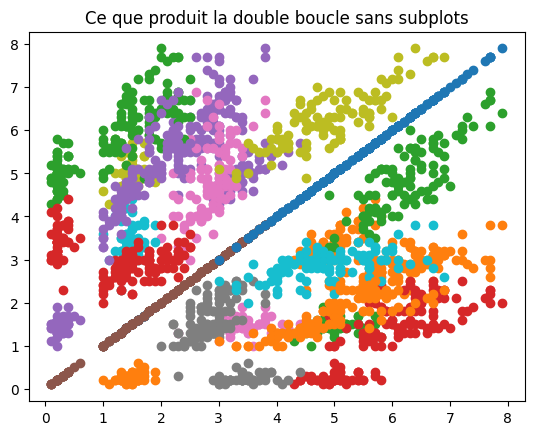

In [ ]:
# La version naïve : seize nuages empilés sur une seule figure
for i in range(4):
    for j in range(4):
        plt.scatter(x[:, i], x[:, j])
plt.title('Ce que produit la double boucle sans subplots')
plt.show()

### La correction

Il faut une case par combinaison. `plt.subplots(4, 4)` crée la grille, et
`ax[i, j]` désigne la case de la ligne `i`, colonne `j`. La double boucle devient
alors exactement ce qu'on voulait.

Ce type de graphique porte un nom : une matrice de nuages de points, ou
*pair plot*. C'est souvent le tout premier graphique qu'on produit sur un
nouveau jeu de données.

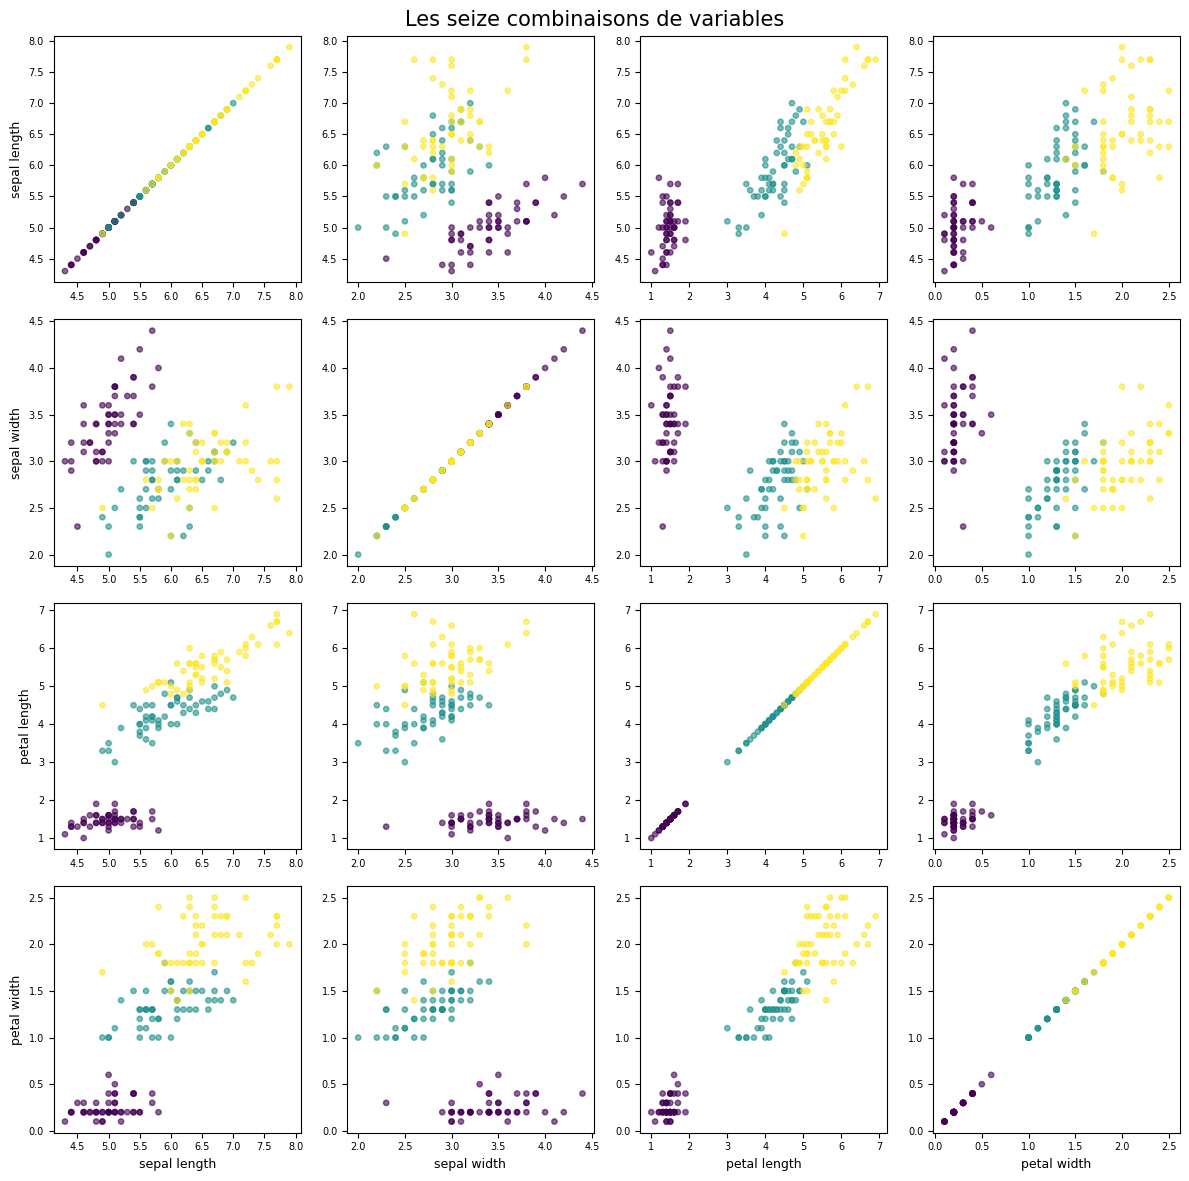

In [ ]:
noms = [n.replace(' (cm)', '') for n in iris.feature_names]

fig, ax = plt.subplots(4, 4, figsize=(12, 12))

for i in range(4):
    for j in range(4):
        ax[i, j].scatter(x[:, j], x[:, i], c=y, alpha=0.6, s=15)
        # Les noms de variables uniquement sur les bords, sinon c'est illisible
        if i == 3:
            ax[i, j].set_xlabel(noms[j], fontsize=9)
        if j == 0:
            ax[i, j].set_ylabel(noms[i], fontsize=9)

        ax[i, j].tick_params(labelsize=7)

fig.suptitle('Les seize combinaisons de variables', fontsize=15)
plt.tight_layout()
plt.show()

Trois choses se lisent immédiatement sur cette grille.

La diagonale ne sert à rien : chaque variable y est tracée contre elle-même, ce
qui donne toujours une droite. Dans un vrai pair plot, on y met un histogramme à
la place.

La grille est symétrique. La case en ligne 1 colonne 2 contient la même
information que la case ligne 2 colonne 1, avec les axes inversés. Il n'y a donc
que six graphiques réellement distincts sur les seize.

Et surtout, les cases impliquant les variables de pétale, les deux dernières,
séparent bien mieux les couleurs que celles du sépale. Le message est clair :
si on ne devait garder que deux variables pour classer ces fleurs, ce seraient
celles-là.

### À tester

Remplace la diagonale par un histogramme. La condition `if i == j` permet de
choisir quoi tracer dans chaque case.

## 4. La troisième dimension

Puisque quatre variables ne tiennent pas sur un plan, la tentation est d'en
afficher trois d'un coup. Matplotlib le permet avec l'argument
`projection='3d'`.

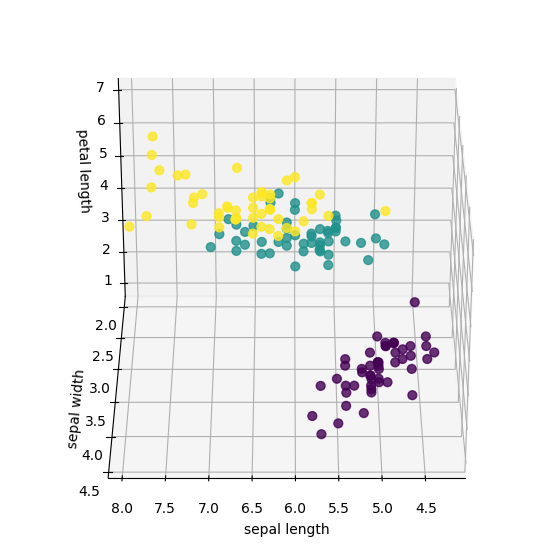

In [ ]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:, 0], x[:, 1], x[:, 2], c=y, s=40, alpha=0.8)
ax.set_xlabel(noms[0])
ax.set_ylabel(noms[1])
ax.set_zlabel(noms[2])
ax.view_init(elev=30, azim=90) # l'angle de vue
plt.show()

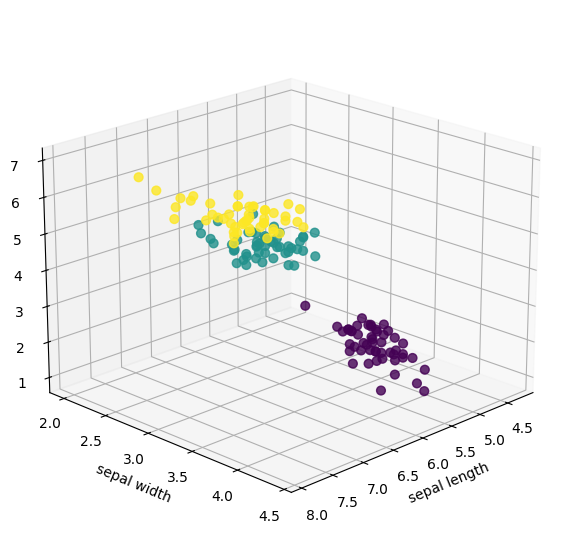

In [ ]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:, 0], x[:, 1], x[:, 2], c=y, s=40, alpha=0.8)
ax.set_xlabel(noms[0])
ax.set_ylabel(noms[1])
ax.set_zlabel(noms[2])
ax.view_init(elev=20, azim=45) # l'angle de vue
plt.show()

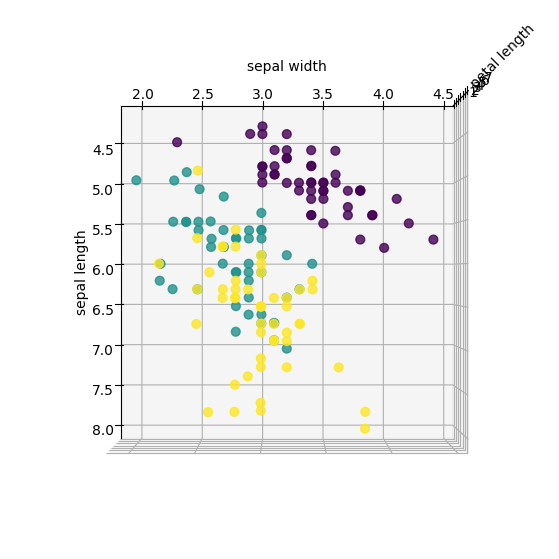

In [ ]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x[:, 0], x[:, 1], x[:, 2], c=y, s=40, alpha=0.8)

ax.set_xlabel(noms[0])
ax.set_ylabel(noms[1])
ax.set_zlabel(noms[2])
ax.view_init(elev=90, azim=360)     # l'angle de vue
plt.show()

Deux remarques de méthode.

`fig.add_subplot(111, projection='3d')` est plus fiable que
`plt.axes(projection='3d')` : on maîtrise la figure dans laquelle on travaille.
Avec `plt.axes`, Matplotlib peut se raccrocher à une figure ouverte
précédemment, et le graphique part alors dans le vide sans message d'erreur.

`view_init(elev, azim)` fixe l'angle de vue. Il faut le régler à la main, car
l'angle par défaut est rarement le bon, et une image fixe ne se fait pas tourner.

Sur le fond, la 3D déçoit souvent. Une projection à plat d'un nuage en trois
dimensions cache autant qu'elle montre : des points éloignés peuvent se
superposer, et la profondeur ne se perçoit pas sans rotation. En pratique, deux
graphiques 2D côte à côte informent généralement mieux.

Si tu veux pouvoir faire tourner le nuage, Plotly le fait sans configuration :

```python
import plotly.express as px
fig = px.scatter_3d(x=x[:, 0], y=x[:, 1], z=x[:, 2], color=y)
fig.show()
```

Attention toutefois : les graphiques Plotly ne s'affichent pas sur GitHub. Si tu
publies ce notebook, garde une version Matplotlib.

In [ ]:
import plotly.express as px
fig = px.scatter_3d(x=x[:, 0], y=x[:, 1], z=x[:, 2], color=y)
fig.show()

### Les surfaces

`plot_surface` trace une fonction de deux variables. La difficulté n'est pas le
tracé, c'est la préparation des données : il faut une grille de points, pas deux
vecteurs.

C'est le rôle de `np.meshgrid`. À partir de deux vecteurs de 100 valeurs, il
construit deux tableaux 100x100 contenant toutes les combinaisons possibles.

In [ ]:
# Deux vecteurs simples pour comprendre meshgrid
a = np.array([1, 2, 3])
b = np.array([10, 20])

A, B = np.meshgrid(a, b)
print('A =\n', A)
print('B =\n', B)
print('Formes :', A.shape, B.shape)

A =
 [[1 2 3]
 [1 2 3]]
B =
 [[10 10 10]
 [20 20 20]]
Formes : (2, 3) (2, 3)


`A` répète les valeurs de `a` sur chaque ligne, `B` répète celles de `b` sur
chaque colonne. En superposant les deux, on obtient toutes les paires
possibles : (1,10), (2,10), (3,10), (1,20), et ainsi de suite.

C'est exactement ce qu'il faut pour évaluer une fonction sur une grille.

Forme de la grille : (100, 100) (100, 100) (100, 100)


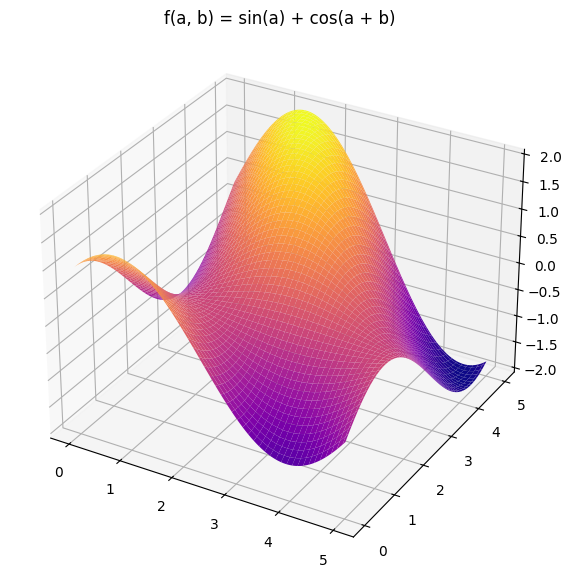

In [ ]:
def f(a, b):
    return np.sin(a) + np.cos(a + b)
# XX, YY, ZZ en majuscules doubles pour ne pas écraser x et y, les données iris
XX = np.linspace(0, 5, 100)
YY = np.linspace(0, 5, 100)
XX, YY = np.meshgrid(XX, YY)
ZZ = f(XX, YY)

print('Forme de la grille :', XX.shape, YY.shape, ZZ.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XX, YY, ZZ, cmap='plasma')
ax.set_title('f(a, b) = sin(a) + cos(a + b)')
plt.show()

Le choix des noms `XX`, `YY`, `ZZ` n'est pas cosmétique. Dans la version
d'origine de ce notebook, la grille s'appelait `X` et `Y`, puis une cellule plus
bas écrasait `X` avec un autre jeu de données. Réexécuter une cellule de contour
après coup produisait alors une erreur incompréhensible.

C'est un piège classique des notebooks : contrairement à un script, les cellules
peuvent être exécutées dans n'importe quel ordre, et les variables persistent.
Deux règles simples évitent la plupart des problèmes. Ne jamais réutiliser un
nom de variable pour deux choses différentes dans un même notebook. Et
redémarrer le noyau puis tout réexécuter avant de publier, pour vérifier que
l'ensemble tient debout dans l'ordre.

## 5. Les histogrammes

Un histogramme découpe les valeurs en intervalles, les *bins*, et compte combien
d'observations tombent dans chacun. C'est le graphique à faire en premier sur
une variable qu'on ne connaît pas : il révèle l'échelle, la forme de la
distribution et les valeurs aberrantes.

Ici encore, la version naïve pose problème.

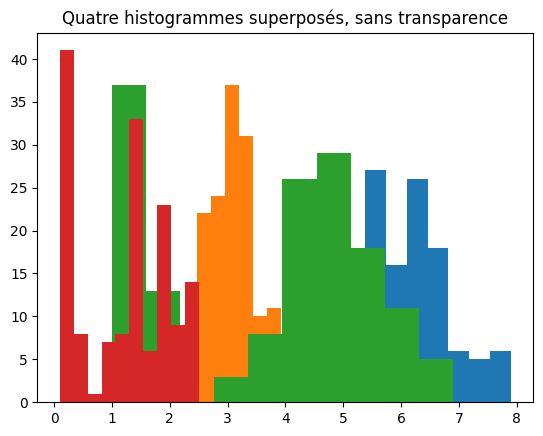

In [ ]:
# Version naïve : les quatre histogrammes se recouvrent, opaques
for i in range(4):
    plt.hist(x[:, i])

plt.title('Quatre histogrammes superposés, sans transparence')
plt.show()

Les derniers tracés masquent les précédents, et rien n'indique quelle couleur
correspond à quelle variable. Deux corrections suffisent : de la transparence,
et des labels avec une légende.

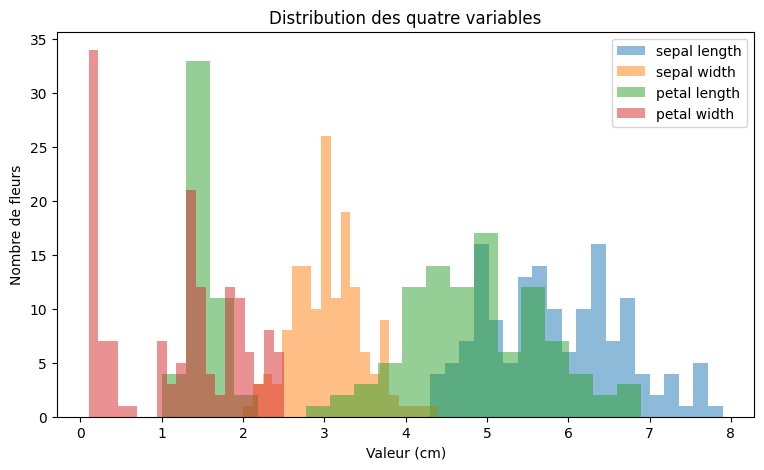

In [ ]:
plt.figure(figsize=(9, 5))

for i in range(4):
    plt.hist(x[:, i], bins=20, alpha=0.5, label=noms[i])

plt.legend()
plt.xlabel('Valeur (cm)')
plt.ylabel("Nombre de fleurs")
plt.title('Distribution des quatre variables')
plt.show()

On voit maintenant que les quatre variables occupent des plages très
différentes : la largeur du pétale tourne autour de 1 cm, la longueur du sépale
autour de 6. Cette différence d'échelle est une information importante, car
beaucoup d'algorithmes y sont sensibles et exigent une normalisation préalable.

La largeur du pétale montre par ailleurs deux bosses bien distinctes. Une
distribution à deux modes signale presque toujours un mélange de populations,
ici les espèces. C'est une confirmation de ce que le pair plot avait suggéré.

### Une grille est souvent plus lisible

Superposer permet de comparer les échelles ; séparer permet de voir chaque forme
en détail. Les deux se justifient selon la question posée.

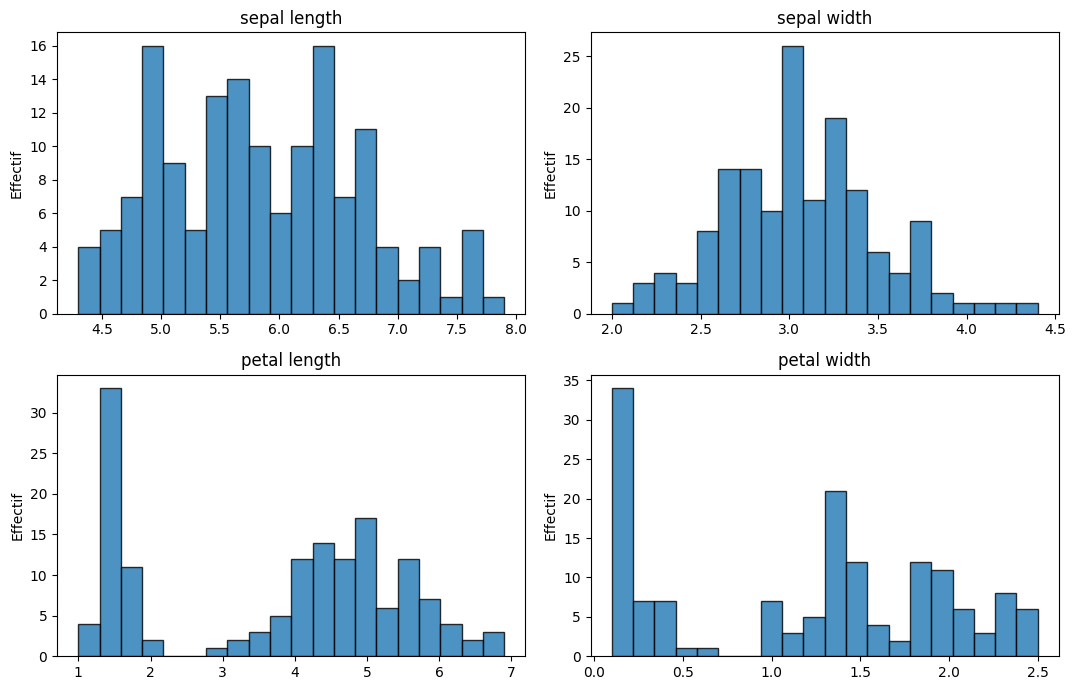

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax = ax.flatten() # passe de la grille 2D à un tableau 1D

for i in range(4):
    ax[i].hist(x[:, i], bins=20, edgecolor='black', alpha=0.8)
    ax[i].set_title(noms[i])
    ax[i].set_ylabel('Effectif')

plt.tight_layout()
plt.show()

### À tester

Fais varier `bins` avec 5, 20 puis 100 sur la largeur du pétale. Trop peu de
bins efface les deux modes, trop de bins les noie dans le bruit. Il n'existe pas
de valeur correcte universelle : c'est un choix, et il change ce qu'on croit
voir.

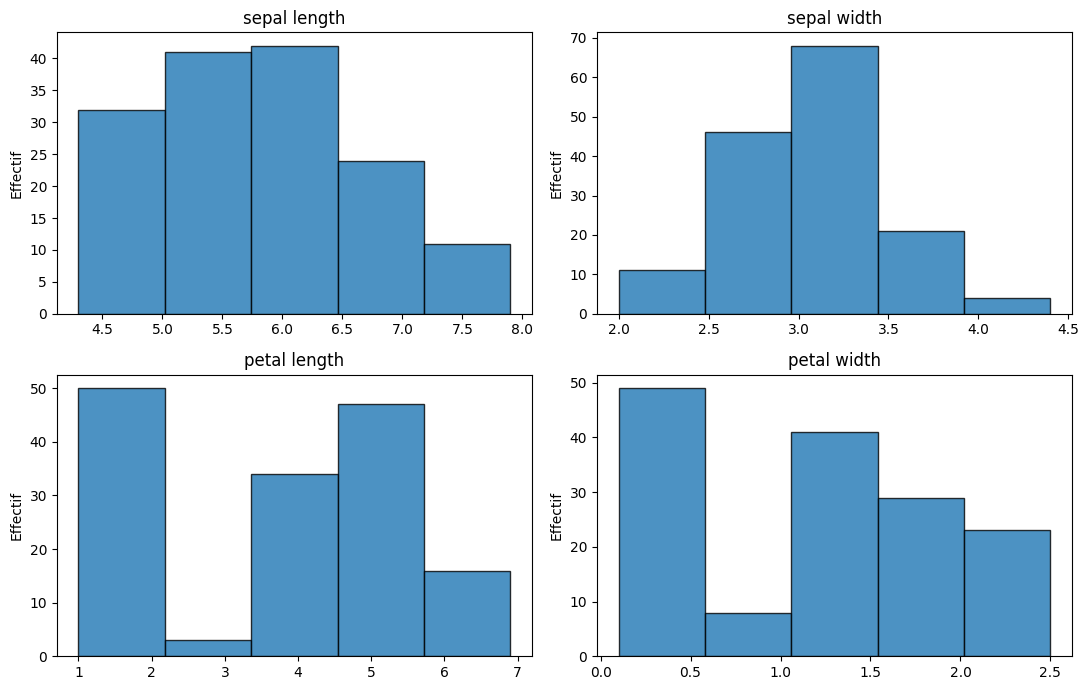

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax = ax.flatten() # passe de la grille 2D à un tableau 1D

for i in range(4):
    ax[i].hist(x[:, i], bins=5, edgecolor='black', alpha=0.8)
    ax[i].set_title(noms[i])
    ax[i].set_ylabel('Effectif')

plt.tight_layout()
plt.show()

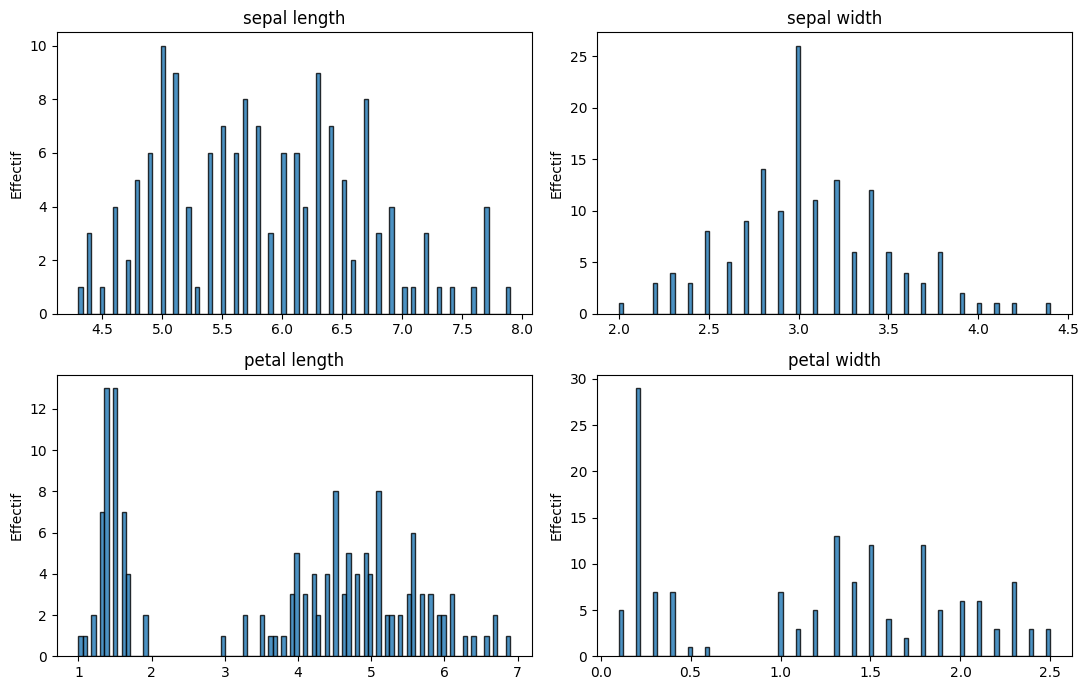

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax = ax.flatten() # passe de la grille 2D à un tableau 1D

for i in range(4):
    ax[i].hist(x[:, i], bins=100, edgecolor='black', alpha=0.8)
    ax[i].set_title(noms[i])
    ax[i].set_ylabel('Effectif')

plt.tight_layout()
plt.show()

### hist2d : la densité en deux dimensions

Quand deux variables ont beaucoup de points superposés, un nuage classique ne
montre plus les zones de concentration, même avec de la transparence.
`hist2d` découpe le plan en cases et compte les points dans chacune.

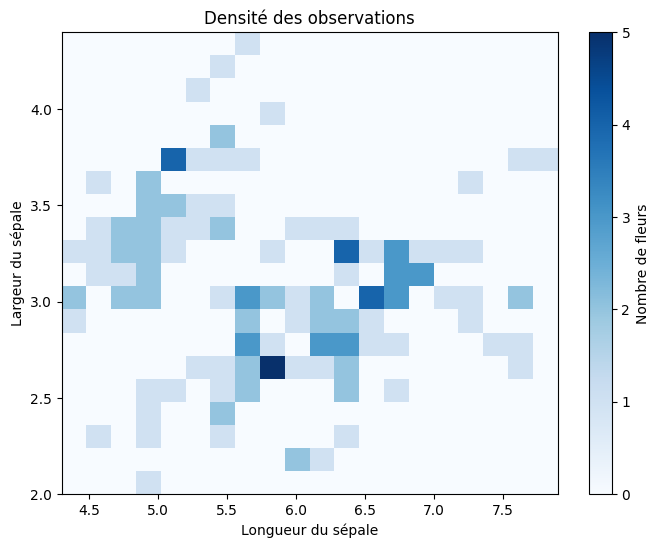

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist2d(x[:, 0], x[:, 1], bins=20, cmap='Blues')
plt.colorbar(label='Nombre de fleurs')
plt.xlabel('Longueur du sépale')
plt.ylabel('Largeur du sépale')
plt.title('Densité des observations')
plt.show()

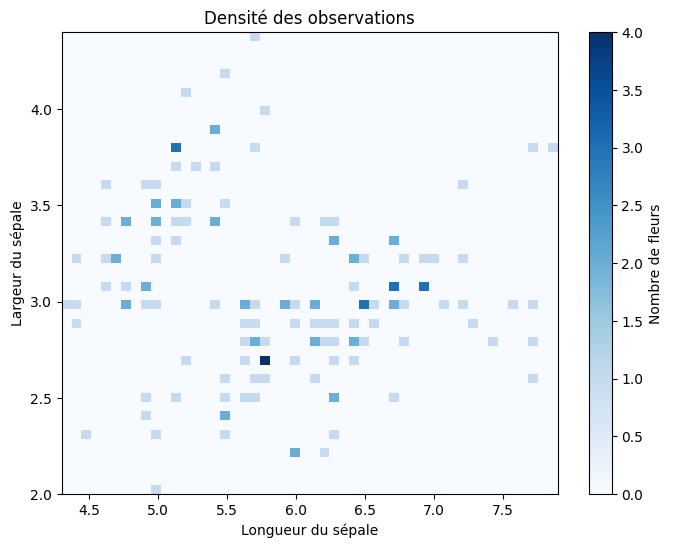

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist2d(x[:, 0], x[:, 1], bins=50, cmap='Blues')
plt.colorbar(label='Nombre de fleurs')
plt.xlabel('Longueur du sépale')
plt.ylabel('Largeur du sépale')
plt.title('Densité des observations')
plt.show()

Le compromis est clair : on gagne la densité, on perd les classes. `hist2d`
n'accepte pas d'argument `c`, puisque la couleur est déjà utilisée pour le
comptage. Les deux graphiques sont complémentaires, pas concurrents.

### Un histogramme sur une image

Une image en niveaux de gris est un tableau à deux dimensions d'entiers entre 0
et 255. Son histogramme donne la répartition des intensités lumineuses, ce qui
permet de dire si l'image est sombre, claire, ou contrastée.

Le point technique est `ravel`, qui aplatit le tableau 2D en un long vecteur.
`hist` ne travaille que sur une dimension.

Forme de l'image : (768, 1024)
Après ravel : (786432,)
Valeurs : de 0 à 250


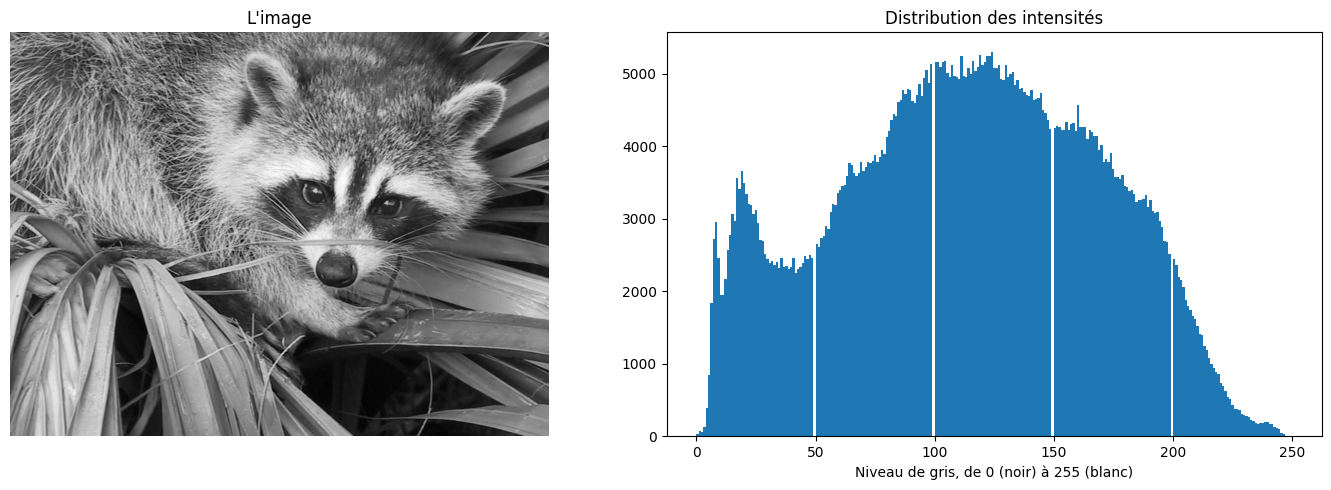

In [ ]:
from scipy import datasets

face = datasets.face(gray=True)

print('Forme de l\'image :', face.shape)
print('Après ravel :', face.ravel().shape)
print('Valeurs : de', face.min(), 'à', face.max())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].imshow(face, cmap='gray')
ax[0].axis('off')
ax[0].set_title("L'image")

ax[1].hist(face.ravel(), bins=255)
ax[1].set_title('Distribution des intensités')
ax[1].set_xlabel('Niveau de gris, de 0 (noir) à 255 (blanc)')

plt.tight_layout()
plt.show()

Si `datasets.face` échoue, deux causes possibles : le module a changé de place
selon les versions de SciPy, et l'image est téléchargée au premier appel, ce qui
suppose une connexion et le paquet `pooch`. Une solution de repli sans réseau :

```python
from skimage import data
face = data.camera()
```

Ce que l'histogramme raconte : le pic principal indique la tonalité dominante de
l'image, et l'étalement des valeurs mesure le contraste. Une image très
contrastée occupe toute la largeur, une image terne se concentre au milieu.
C'est le graphique sur lequel reposent les corrections automatiques de
luminosité.

array([[200, 200, 200, ..., 189, 190, 190],
       [200, 199, 199, ..., 190, 190, 190],
       [199, 199, 199, ..., 190, 190, 190],
       ...,
       [ 25,  25,  27, ..., 139, 122, 147],
       [ 25,  25,  26, ..., 158, 141, 168],
       [ 25,  25,  27, ..., 151, 152, 149]], dtype=uint8)
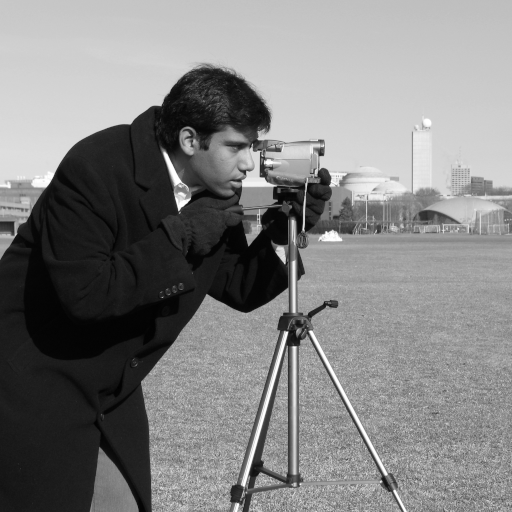

In [ ]:
from skimage import data
face = data.camera()
face

## 6. Les courbes de niveau

Une surface 3D est jolie mais difficile à lire précisément : la perspective
déforme, et une partie du relief est cachée. Les courbes de niveau représentent
la même information à plat, exactement comme une carte de randonnée.

On réutilise la grille de la section 4.

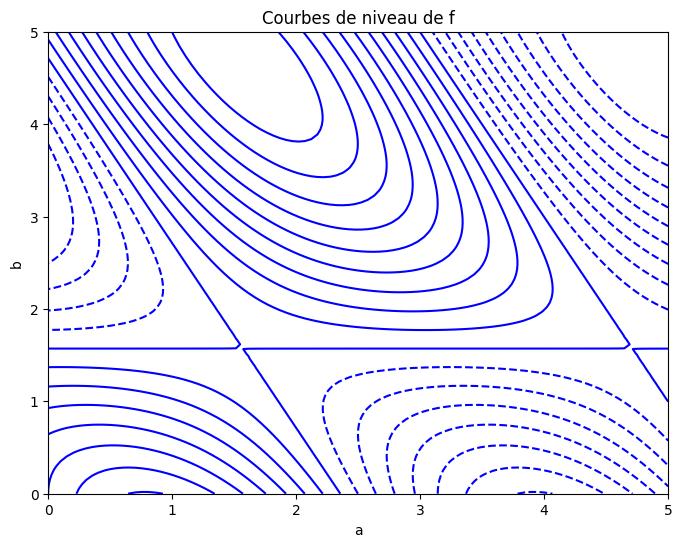

In [ ]:
plt.figure(figsize=(8, 6))
plt.contour(XX, YY, ZZ, 20, colors='blue')
plt.xlabel('a')
plt.ylabel('b')
plt.title('Courbes de niveau de f')
plt.show()

Le `20` est le nombre de niveaux tracés. Chaque courbe relie les points où la
fonction prend la même valeur.

Une convention est à connaître : quand on impose une couleur unique, Matplotlib
trace les valeurs négatives en pointillés et les positives en trait plein.
C'est le seul moyen de distinguer un creux d'une bosse sans échelle de couleurs.
Les cercles concentriques marquent les extrema, un maximum si les traits sont
pleins, un minimum s'ils sont pointillés.

### La version remplie

`contourf`, avec un f pour *filled*, colore les intervalles entre les courbes.
Plus immédiat à lire, au prix d'un peu de précision.

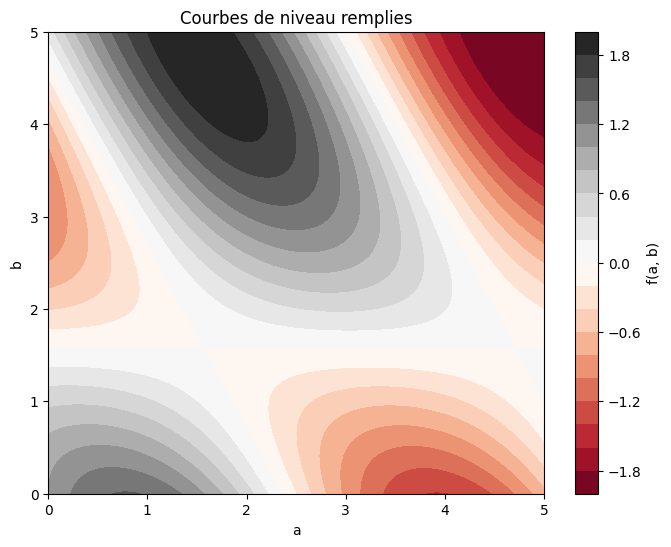

In [ ]:
plt.figure(figsize=(8, 6))
plt.contourf(XX, YY, ZZ, 20, cmap='RdGy')
plt.colorbar(label='f(a, b)')
plt.xlabel('a')
plt.ylabel('b')
plt.title('Courbes de niveau remplies')
plt.show()

`RdGy` est une palette divergente, du rouge au gris en passant par le blanc.
Elle convient quand il existe un point de référence, ici le zéro. Pour une
grandeur qui va simplement de peu à beaucoup, une palette séquentielle comme
`viridis` serait plus juste.

### Pourquoi c'est utile en machine learning

Les courbes de niveau servent à visualiser une fonction de coût. L'entraînement
d'un modèle revient à en chercher le minimum, et la descente de gradient trace
un chemin sur ce relief. Les graphiques qu'on voit dans les cours d'optimisation
sont exactement des `contour` de ce type.

## 7. imshow et la matrice de corrélation

`imshow` affiche un tableau à deux dimensions, chaque valeur devenant un pixel
coloré. Une image en est un cas particulier, mais l'usage le plus fréquent en
analyse de données est l'affichage d'une matrice.

La matrice de corrélation contient, pour chaque paire de variables, un nombre
entre -1 et 1 mesurant leur degré de relation linéaire.

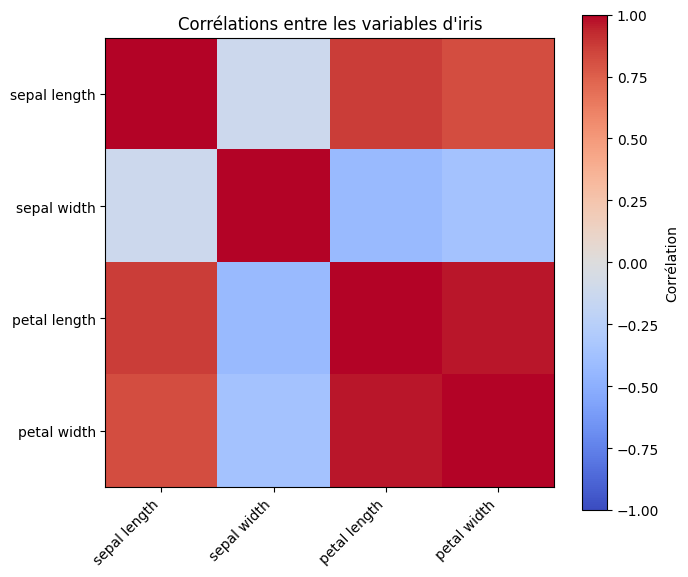

In [ ]:
plt.figure(figsize=(7, 6))
plt.imshow(np.corrcoef(x.T), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Corrélation')

plt.xticks(range(4), noms, rotation=45, ha='right')
plt.yticks(range(4), noms)
plt.title('Corrélations entre les variables d\'iris')
plt.tight_layout()
plt.show()

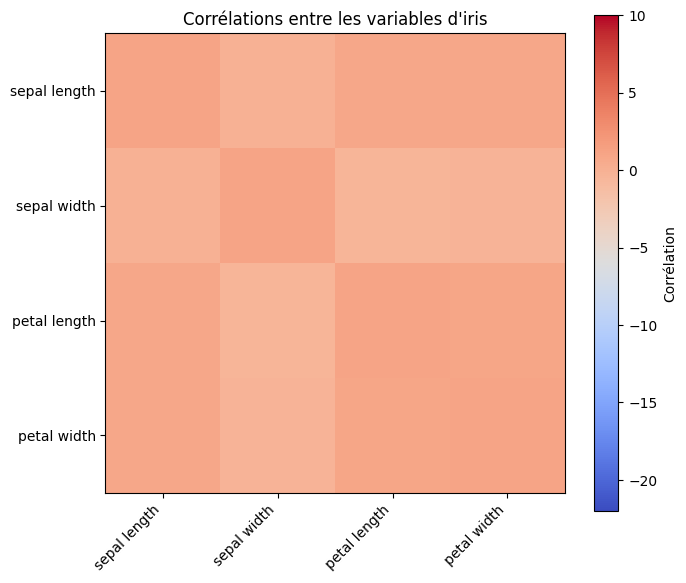

In [ ]:
plt.figure(figsize=(7, 6))
plt.imshow(np.corrcoef(x.T), cmap='coolwarm', vmin=10, vmax=-20)
plt.colorbar(label='Corrélation')

plt.xticks(range(4), noms, rotation=45, ha='right')
plt.yticks(range(4), noms)
plt.title('Corrélations entre les variables d\'iris')
plt.tight_layout()
plt.show()

Trois détails comptent dans cette cellule.

Le `.T` d'abord. `np.corrcoef` calcule les corrélations entre les lignes du
tableau qu'on lui donne. Or dans `x`, les lignes sont les fleurs et les colonnes
les variables. Sans transposition, on obtiendrait une matrice 150x150 de
corrélations entre fleurs, ce qui n'a aucun sens. Le `.T` échange lignes et
colonnes et donne bien une matrice 4x4.

`vmin=-1, vmax=1` ensuite. Sans ces bornes, Matplotlib cale l'échelle sur les
valeurs présentes et le blanc central ne tombe plus sur zéro. Deux matrices
tracées sans ces bornes ne seraient pas comparables entre elles.

La palette divergente enfin. Le blanc marque l'absence de relation, le rouge les
corrélations positives, le bleu les négatives. Avec `viridis`, cette lecture
disparaîtrait.

Sur iris, la diagonale est rouge vif, puisque chaque variable est parfaitement
corrélée avec elle-même. Et longueur et largeur du pétale sont très fortement
liées : elles portent presque la même information.

### Sur un jeu de données plus large

L'intérêt du graphique grandit avec le nombre de variables. Sur les trente
variables du jeu de données breast cancer, la structure saute aux yeux.

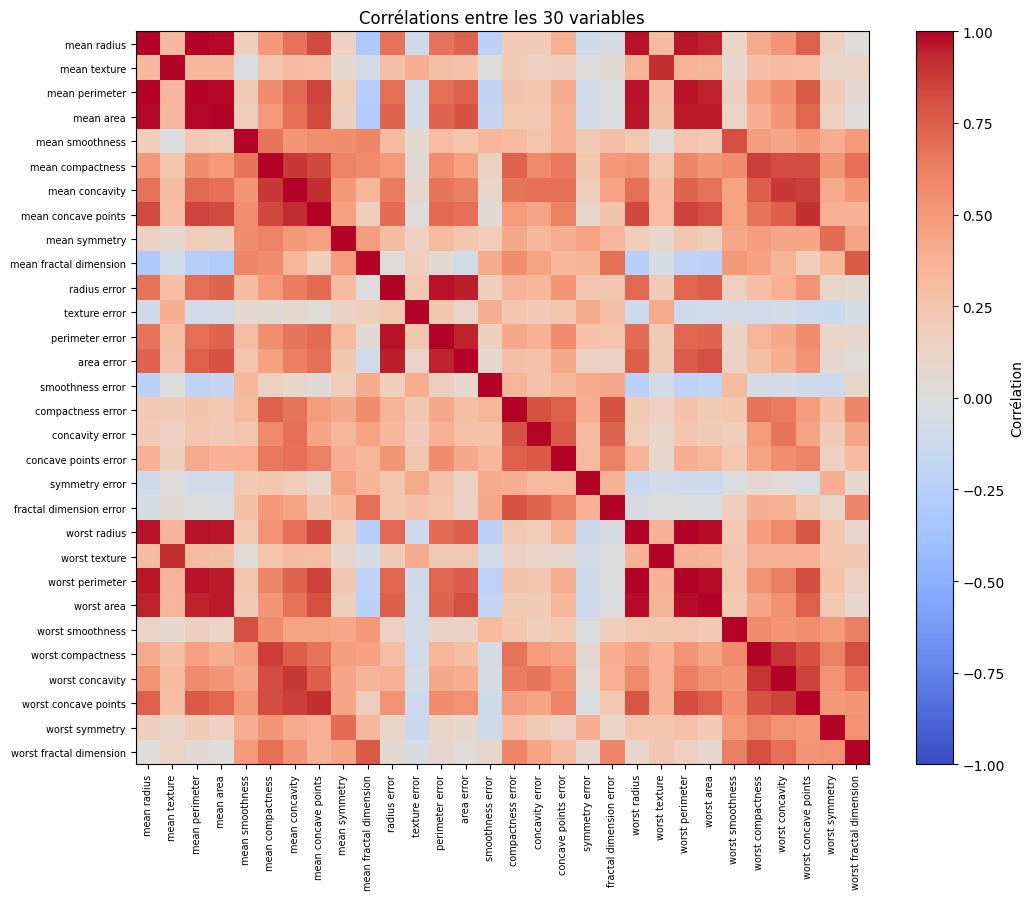

In [ ]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_cancer = cancer.data # (569, 30), nom distinct pour éviter les collisions
noms_cancer = cancer.feature_names

plt.figure(figsize=(11, 9))
plt.imshow(np.corrcoef(X_cancer.T), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Corrélation')

plt.xticks(range(len(noms_cancer)), noms_cancer, rotation=90, fontsize=7)
plt.yticks(range(len(noms_cancer)), noms_cancer, fontsize=7)

plt.title('Corrélations entre les 30 variables')
plt.tight_layout()
plt.show()

Des blocs rouges apparaissent nettement. Ce n'est pas un hasard : ce jeu de
données contient chaque mesure en trois versions, la moyenne, l'erreur type et
la pire valeur. Ces trois versions sont naturellement très corrélées entre
elles.

C'est précisément l'usage de ce graphique. Des variables fortement corrélées
apportent une information redondante, ce qui gêne certains modèles et allonge
inutilement les calculs. Le repérer avant d'entraîner quoi que ce soit fait
gagner du temps.

## 8. Mémo

### Quel graphique pour quelle question

| Question | Graphique |
|---|---|
| Mes classes sont-elles séparables ? | `scatter` avec `c=y` |
| Quelle paire de variables sépare le mieux ? | grille de `scatter` |
| Comment se répartit une variable ? | `hist` |
| Où mes points se concentrent-ils ? | `hist2d` |
| Quelles variables sont redondantes ? | `imshow` sur `np.corrcoef` |
| Où sont les minima d'une fonction ? | `contour` |

### Encoder plusieurs variables sur un même graphique

| Canal | Argument | Type de valeur |
|---|---|---|
| position | `x`, `y` | deux vecteurs |
| couleur | `c` | un vecteur, avec `cmap` |
| taille | `s` | un vecteur |
| transparence | `alpha` | une seule valeur |

Quatre variables sur un plan, c'est le maximum raisonnable. Au-delà, le
graphique devient plus difficile à lire qu'un tableau.

### Les erreurs rencontrées dans ce notebook

| Symptôme | Cause | Solution |
|---|---|---|
| Tous les tracés se superposent | pas de nouvelle figure dans la boucle | `subplots` et `ax[i, j]` |
| Les histogrammes se masquent | pas de transparence | `alpha=0.5` et `legend()` |
| Erreur incompréhensible après réexécution | variable écrasée plus bas | noms distincts, redémarrer le noyau |
| Le graphique 3D n'apparaît pas | `plt.axes` accroché à une figure déjà affichée | `fig.add_subplot(111, projection='3d')` |

## 9. Exercices

**Exercice 1**

Reproduis la grille de la section 3, mais place un histogramme sur la diagonale
au lieu du nuage inutile. La condition `if i == j` permet de choisir quoi tracer
dans chaque case.

**Exercice 2**

Trouve la paire de variables qui sépare le mieux les trois espèces, puis trace
ce seul graphique en grand, avec une vraie légende indiquant les noms des
espèces plutôt qu'une barre de couleur. Cherche comment tracer trois `scatter`
successifs, un par classe, en filtrant avec `x[y == 0]`.

**Exercice 3**

Calcule la matrice de corrélation d'iris et repère la paire de variables la plus
corrélée, sans la lire sur le graphique. Les fonctions `np.argmax` et
`np.triu_indices` sont utiles pour ne regarder que la moitié supérieure de la
matrice, diagonale exclue.

## Pour continuer

La bibliothèque Seaborn produit le pair plot de la section 3 en une seule ligne,
avec les histogrammes sur la diagonale. Elle est construite au-dessus de
Matplotlib, donc tout ce qui a été vu ici reste valable.

```python
import seaborn as sns
sns.pairplot(sns.load_dataset('iris'), hue='species')
```

Ce qui ne dispense pas de savoir le faire à la main : dès qu'un graphique sort
des cas prévus, il faut redescendre au niveau de Matplotlib.

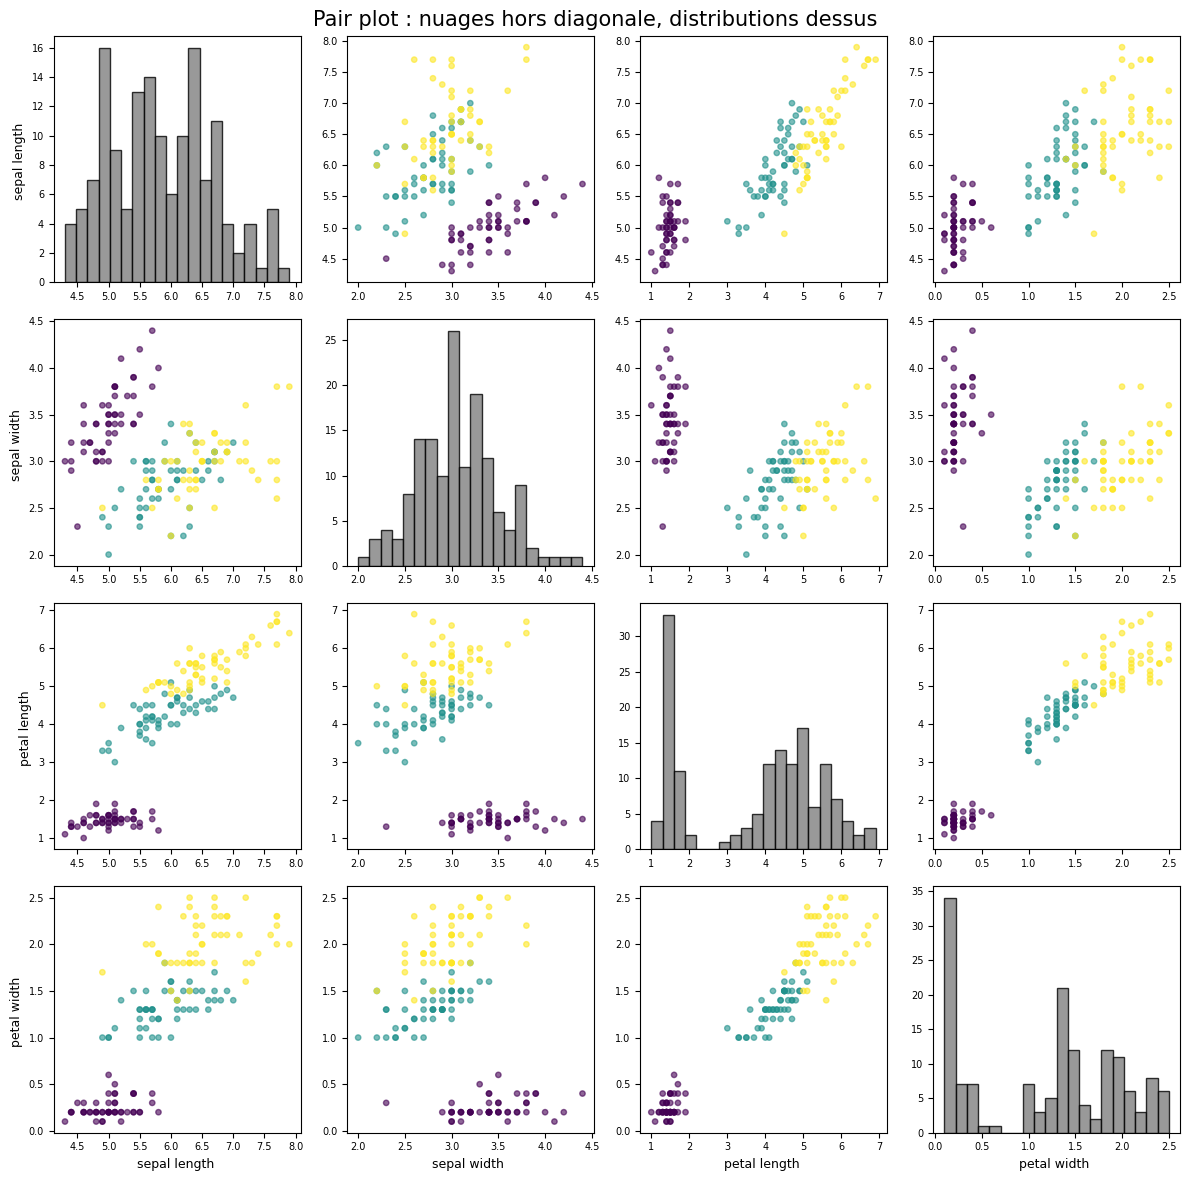

In [ ]:
# Exercice 1
noms = [n.replace('(cm)','') for n in iris.feature_names]
fig, ax = plt.subplots(4, 4, figsize=(12, 12))
for i in range(4):
    for j in range(4):
        if i == j: # sur la diagonale : un histogramme
            ax[i, j].hist(x[:, i], bins=20, color='gray', edgecolor='black', alpha=0.8)
        else: # ailleurs : le nuage de points
            ax[i, j].scatter(x[:, j], x[:, i], c=y, alpha=0.6, s=15)
        if i == 3:
            ax[i, j].set_xlabel(noms[j], fontsize=9) # noms en bas seulement
        if j == 0:
            ax[i, j].set_ylabel(noms[i], fontsize=9) # et à gauche seulement
        ax[i, j].tick_params(labelsize=7)
fig.suptitle('Pair plot : nuages hors diagonale, distributions dessus', fontsize=15)
plt.tight_layout()
plt.show()

Le seul changement est le `if i == j`, qui distingue les cases de la diagonale.
Tout le reste de la boucle est inchangé.

Ce détail transforme le graphique. La diagonale ne gaspille plus de place à
tracer une droite sans intérêt : elle porte maintenant la distribution de chaque
variable. En un seul coup d'oeil, on obtient les relations entre variables et la
forme de chacune prise isolément.

Attention à un point : les histogrammes de la diagonale ont un axe vertical qui
n'a rien à voir avec celui des nuages de la même ligne. C'est un effectif d'un
côté, une mesure en centimètres de l'autre. Le graphique est donc un peu
tricheur, et c'est assumé l'usage est tellement répandu que Seaborn le produit
ainsi par défaut.

Ce qu'on lit ici : les deux histogrammes du bas, ceux des variables de pétale,
montrent deux bosses nettement séparées. Ceux du haut, pour le sépale, donnent
une seule masse. C'est cohérent avec les nuages, où les couleurs se séparent
bien mieux à droite qu'à gauche.

In [ ]:
# Exercice 2
scores = []
for a in range(4):
    for b in range(a + 1, 4): # a < b : chaque paire une seule fois
        # centre de chaque classe dans le plan (a, b)
        centres = np.array([x[y == k][:, [a, b]].mean(axis=0) for k in range(3)])
        # distance entre les deux classes les plus proches
        ecart = min(np.linalg.norm(centres[p] - centres[q])
                    for p in range(3) for q in range(p + 1, 3))
        # étalement moyen des classes
        dispersion = np.mean([x[y == k][:, [a, b]].std(axis=0).mean() for k in range(3)])
        scores.append((ecart / dispersion, a, b))
for score, a, b in sorted(scores, reverse=True):
    print(f'{score:5.2f}   {noms[a]} / {noms[b]}')

 5.02   petal length  / petal width 
 3.59   sepal width  / petal length 
 3.25   sepal length  / petal length 
 2.78   sepal length  / petal width 
 2.77   sepal width  / petal width 
 1.64   sepal length  / sepal width 


Plutôt que de choisir à l'oeil, on mesure. L'idée est simple : une bonne paire
de variables est celle où les classes sont loin les unes des autres, et où
chaque classe reste compacte.

On calcule donc le centre de chaque espèce, on prend la distance entre les deux
espèces les plus proches c'est le cas le plus difficile qui compte, et on
divise par l'étalement moyen. Un score élevé signifie des groupes bien séparés.

Le filtre `x[y == 0]` est la mécanique centrale ici. La comparaison `y == 0`
produit un tableau de 150 booléens, et le passer entre crochets ne garde que les
lignes où c'est vrai. C'est le masque booléen de NumPy, on le retrouvera
partout.

Le classement donne nettement la longueur et la largeur du pétale en tête, avec
un score de 5,0 contre 1,6 pour la pire paire. C'est la confirmation chiffrée de
ce que la grille laissait deviner.

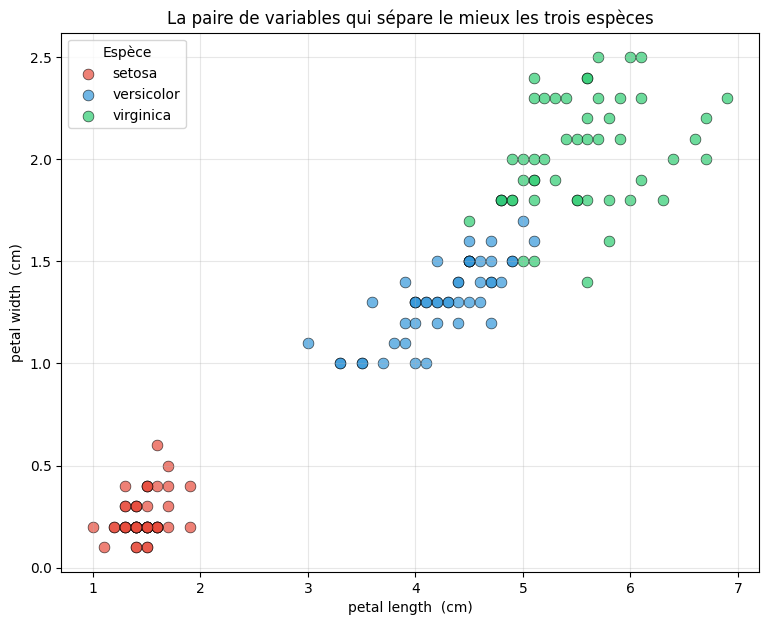

In [ ]:
couleurs = ['#e74c3c', '#3498db', '#2ecc71']
a, b = 2, 3 # longueur et largeur du pétale

plt.figure(figsize=(9, 7))

for k in range(3):
    # un scatter par espèce
    plt.scatter(x[y == k][:, a], x[y == k][:, b], color=couleurs[k], label=iris.target_names[k], alpha=0.7, s=60, edgecolors='black', linewidths=0.5)

    # x[y == k][:, a], seulement les fleurs de l'espèce k
    # label=iris.target_names[k], le nom, pas le numéro

plt.xlabel(noms[a] + ' (cm)')
plt.ylabel(noms[b] + ' (cm)')
plt.title('La paire de variables qui sépare le mieux les trois espèces')
plt.legend(title='Espèce')
plt.grid(alpha=0.3)
plt.show()

Trois appels à `scatter` au lieu d'un seul, c'est ce qui permet d'avoir une
légende. Avec `c=y`, Matplotlib ne voit qu'une seule série de points et ne peut
produire qu'une barre de couleur ; en traçant chaque classe séparément, chacune
devient une série avec son propre `label`.

Le résultat vaut la peine d'être regardé. *Setosa* est complètement isolée,
séparable par une simple droite horizontale. *Versicolor* et *virginica* se
touchent sur quelques individus, sans se confondre.

C'est exactement le type de conclusion qu'on cherche avant d'entraîner un
modèle. Ici, une frontière linéaire suffira probablement, et il est même
prévisible que les rares erreurs porteront sur la zone de contact entre les deux
dernières espèces. Un graphique bien choisi vaut souvent une première heure de
modélisation.

In [ ]:
# Exercice 3
correlations = np.corrcoef(x.T) # matrice 4x4

lignes, colonnes = np.triu_indices(4, k=1) # moitié supérieure, diagonale exclue
valeurs = correlations[lignes, colonnes]

meilleur = np.argmax(np.abs(valeurs)) # la plus forte en valeur absolue

print(f'Paire la plus corrélée : {noms[lignes[meilleur]]} / {noms[colonnes[meilleur]]}')
print(f'Corrélation            : {valeurs[meilleur]:.3f}')
print()

print('Classement complet :')
for k in np.argsort(np.abs(valeurs))[::-1]:
    print(f'  {valeurs[k]: .3f}   {noms[lignes[k]]} / {noms[colonnes[k]]}')


Paire la plus corrélée : petal length  / petal width 
Corrélation            : 0.963

Classement complet :
   0.963   petal length  / petal width 
   0.872   sepal length  / petal length 
   0.818   sepal length  / petal width 
  -0.428   sepal width  / petal length 
  -0.366   sepal width  / petal width 
  -0.118   sepal length  / sepal width 


Le point clé est `np.triu_indices(4, k=1)`. Il renvoie les indices du triangle
supérieur d'une matrice 4×4, en excluant la diagonale grâce à `k=1`.

Pourquoi s'en donner la peine : la matrice est symétrique, donc chaque paire y
figure deux fois. Et la diagonale ne contient que des 1, puisqu'une variable est
parfaitement corrélée avec elle-même. Un `argmax` appliqué à la matrice entière
renverrait donc systématiquement une case de la diagonale, ce qui n'apprend
rien.

Sur six paires possibles, on n'en garde ainsi que six et non seize.

L'autre subtilité est le `np.abs`. Une corrélation de -0,9 est aussi forte
qu'une corrélation de +0,9, seul le sens change. Chercher le maximum brut
passerait à côté des relations négatives fortes.

Le résultat : longueur et largeur du pétale, à 0,963. Ces deux variables sont
quasiment interchangeables, ce qui a une conséquence concrète elles apportent
une information largement redondante, et un modèle n'a pas forcément besoin des
deux.

À noter au passage : la paire la plus corrélée est aussi celle qui sépare le
mieux les classes, d'après l'exercice 2. Ce n'est pas contradictoire. La
corrélation mesure la relation entre deux variables, pas leur utilité pour
distinguer des groupes. Ici, les deux mesures de pétale varient ensemble parce
qu'elles reflètent toutes deux la taille de la fleur ce qui est justement ce
qui distingue les espèces.

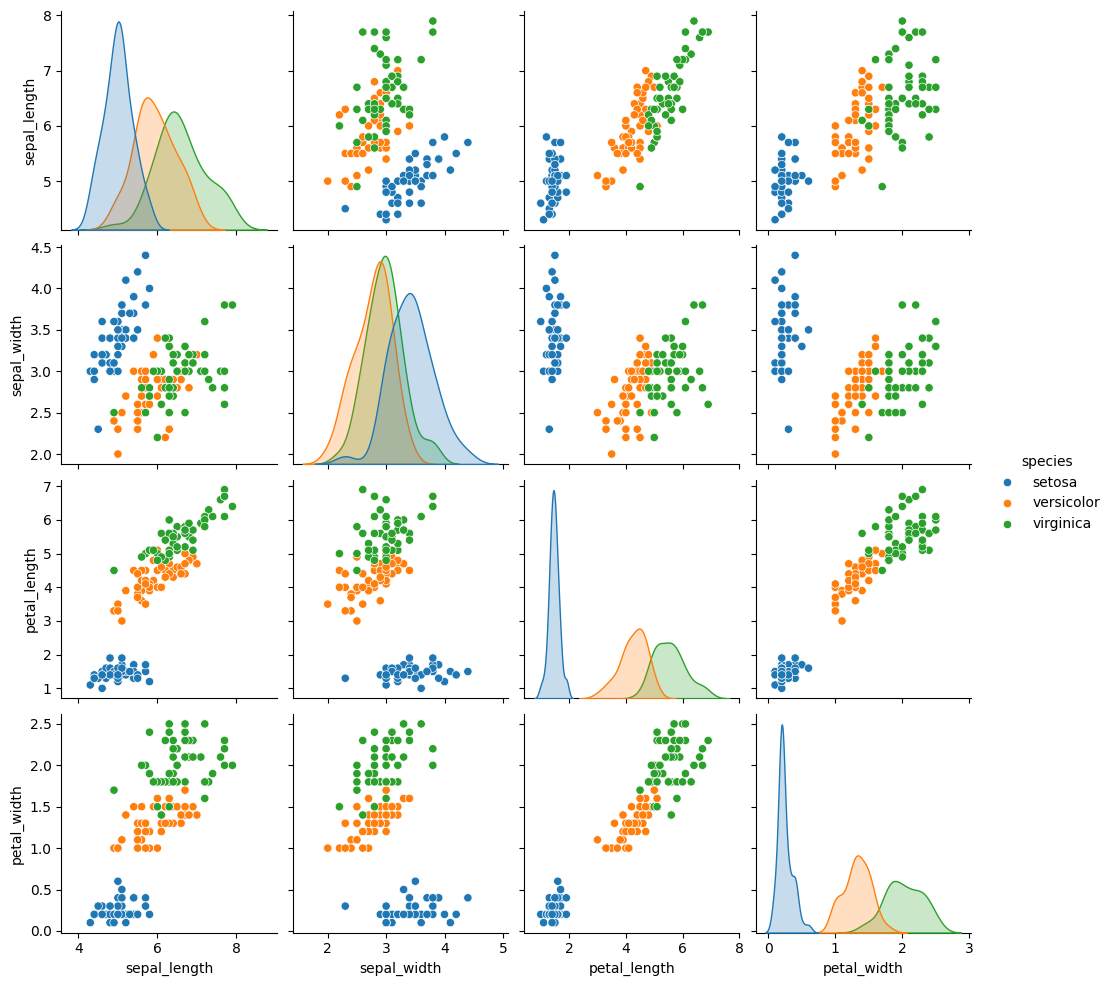

In [ ]:
import seaborn as sns
sns.pairplot(sns.load_dataset('iris'), hue='species')